# The code behind it: simulate the CLT yourself

*Part 1 · Lesson 10 · the code behind it  ·  data: Lending Club · simulation (same as Lesson 10)*

*↩ A companion to [Lesson 10: Sampling distributions & the Central Limit Theorem](10-sampling-distributions-clt.ipynb).*

**↩ Back:** [Lesson 10: Sampling distributions & the Central Limit Theorem](10-sampling-distributions-clt.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset →](10-sampling-distributions-clt~another-dataset.ipynb)

**In Lesson 10 you watched the Central Limit Theorem happen** — thousands of sample means piling up into a
bell curve even though the raw incomes were violently skewed. It looked like magic. This companion **opens
the hood**: you'll build that simulation *yourself*, so "the sampling distribution of the mean" stops being a
picture you're shown and becomes a few lines of code you could write from memory.

Same skewed income population, same headline result — but the focus shifts from *what the CLT means* to **how
you simulate it in Python**. We'll go in the order a programmer actually works:

1. **The goal** — what we're building.
2. **The data in code** — load the population, confirm it's skewed (its $\mu$, $\sigma$, a histogram).
3. **Build it step by step** — draw thousands of samples, average each, and check the spread against $\sigma/\sqrt{n}$.
4. **The idiom** — the explicit `for`-loop vs. the vectorized `(reps, n)` array (and why the array wins).
5. **Refactor into a function** — wrap it as your own reusable `sampling_distribution()`.
6. **Now you code** — predict-then-run exercises.
7. **What you learned** — the coding *and* the statistics.

You don't need Lesson 10 fresh in mind, but it helps. Run each grey cell with **Shift + Enter**, top to bottom.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

## 1) The goal

By the end of this notebook you'll have written the **engine** behind Lesson 10: a function that draws
thousands of random samples from a population, averages each one, and hands back the whole pile of sample
means — the **sampling distribution of the mean**. With it you'll *see* the Central Limit Theorem appear, and
you'll **numerically confirm** the famous $\sqrt{n}$ law (the spread of the sample means equals
$\sigma/\sqrt{n}$). Nothing here needs new statistics; everything is the Python *underneath* the simulation
the core lesson ran for you.

The tools we'll use, and what each is for:

| Tool | What it is | What we use it for |
|---|---|---|
| **pandas** | tables (`DataFrame`) and columns (`Series`) | loading the CSV and pulling out the income column |
| **NumPy** | fast math on whole arrays at once | the random sampling, the averaging, the $\sqrt{n}$ check |
| **matplotlib** | plotting | the population histogram and the CLT small-multiples |

The one new tool is NumPy's **random generator**, `rng = np.random.default_rng(0)`. The `0` is a **seed**: it
fixes the dice so the notebook gives the *same* "random" numbers every time it runs (reproducible results).
Its workhorse method is `rng.choice(pop, size=..., replace=True)` — draw values at random from `pop`.

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sl.use_course_style()
rng = np.random.default_rng(0)   # fixed seed -> reproducible; the learner can change it

# The SAME population as the core lesson: 10,000 borrowers' self-reported annual incomes.
LOANS_URL = 'https://www.openintro.org/data/csv/loans_full_schema.csv'
loans = sl.load_csv('loans.csv', url=LOANS_URL)
print(f'Loaded a {type(loans).__name__} with shape {loans.shape}  (rows, columns)')

Loaded a DataFrame with shape (10000, 55)  (rows, columns)


## 2) The data in code

We'll treat the whole income column as our **population** — every value, no sampling yet — so we get to *know*
the true answer and check our simulation against it.

A programmer's first move is to *interrogate the object*: pull out the column, drop the missing values, and
turn it into a plain NumPy array (fast to sample from). Then compute the two numbers the CLT cares about:

- the **population mean** $\mu$ = `pop.mean()`, and
- the **population standard deviation** $\sigma$ = `pop.std(ddof=0)`.

That `ddof=0` is deliberate: it divides by $n$, which is the **population** SD (we're treating this file as the
*entire* population, not a sample of it). This is the $\sigma$ that the formula $\sigma/\sqrt{n}$ uses, so
matching it later is an honest, apples-to-apples check.

In [2]:
# Pull out the income column, drop missing values, make a NumPy array.
pop = loans['annual_income'].dropna().to_numpy()

mu    = pop.mean()           # the TRUE population mean
sigma = pop.std(ddof=0)      # the TRUE population SD (ddof=0 -> divide by n: this IS the whole population)
N_POP = len(pop)

print(f'population size      N = {N_POP:,} borrowers')
print(f'population mean      mu    = ${mu:,.0f}')
print(f'population SD        sigma = ${sigma:,.0f}')
print(f'median                     = ${np.median(pop):,.0f}')
print(f'min / max                  = ${pop.min():,.0f} / ${pop.max():,.0f}')

population size      N = 10,000 borrowers
population mean      mu    = $79,222
population SD        sigma = $64,731
median                     = $65,000
min / max                  = $0 / $2,300,000


### Confirm it's skewed — *not* a bell curve

The whole drama of the CLT is that the **population** looks nothing like a bell, yet the **averages** will.
So look at the raw shape first. The mean printed just above (about \$79,000) sitting far **above** the median
(\$65,000) is the giveaway: a long thin tail of high earners drags the average up. Let's draw it. *(We clip
the x-axis at \$300k just so the bulk is readable — the tail actually runs all the way to \$2.3 million.)*

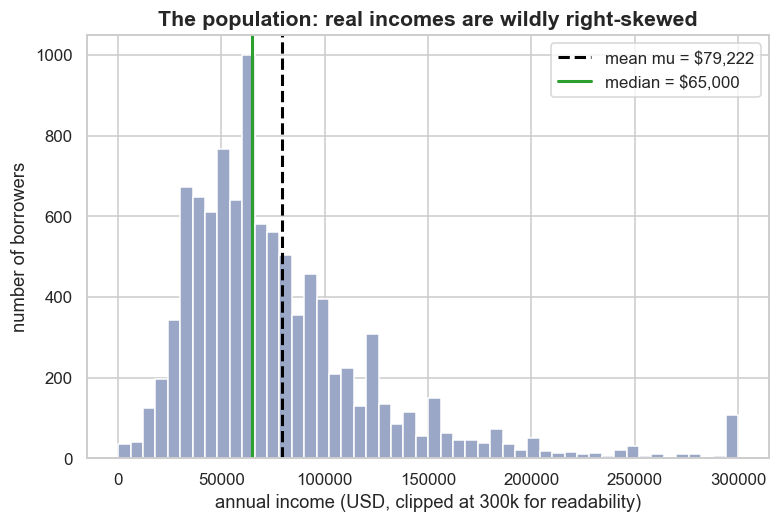

The mean sits to the RIGHT of the median -> a long right tail. This is NOT a bell curve.
Hold that thought: the AVERAGES of samples from it are about to become one.


In [3]:
CLIP = 300_000                              # x-axis cutoff just for readability
clipped = np.clip(pop, None, CLIP)

fig, ax = plt.subplots()
ax.hist(clipped, bins=50, color='#9aa7c7', edgecolor='white')
ax.axvline(mu, color='black', lw=2, ls='--', label=f'mean mu = ${mu:,.0f}')
ax.axvline(np.median(pop), color='#2ca02c', lw=2, label=f'median = ${np.median(pop):,.0f}')
ax.set_xlabel('annual income (USD, clipped at 300k for readability)')
ax.set_ylabel('number of borrowers')
ax.set_title('The population: real incomes are wildly right-skewed')
ax.legend(); plt.show()

print('The mean sits to the RIGHT of the median -> a long right tail. This is NOT a bell curve.')
print('Hold that thought: the AVERAGES of samples from it are about to become one.')

## 3) Build it step by step

Here is the heart of it. The recipe for the sampling distribution of the mean is three plain steps:

1. **draw** a random sample of `n` incomes from the population,
2. **average** that sample to get one sample mean $\bar{x}$,
3. **repeat** thousands of times and collect all the $\bar{x}$ values.

### One sample first

A single sample mean is just *one* random number — a roll of the dice. Draw it twice and you get two
different answers.

In [4]:
n = 30
one_sample = rng.choice(pop, size=n, replace=True)   # draw 30 incomes at random, WITH replacement
xbar = one_sample.mean()                             # average them -> one sample mean
print(f'A sample of {n} incomes had mean   xbar = ${xbar:,.0f}')

xbar2 = rng.choice(pop, size=n, replace=True).mean()
print(f'A second sample of {n} gave        xbar = ${xbar2:,.0f}')
print(f'(true population mean              mu   = ${mu:,.0f})')
print('Different sample -> different mean. xbar wobbles. That wobble has a shape we can map.')

A sample of 30 incomes had mean   xbar = $112,092
A second sample of 30 gave        xbar = $79,273
(true population mean              mu   = $79,222)
Different sample -> different mean. xbar wobbles. That wobble has a shape we can map.


### Why `replace=True`?

We draw **with replacement** (`replace=True`), meaning the same borrower *could* be picked twice in one
sample. That sounds odd, but it's the right choice: it models drawing from an effectively *infinite* stream of
similar borrowers, so a finite population never gets "used up." It's also exactly the assumption under which
$\sigma/\sqrt{n}$ is the **exact** target for the spread — which lets us check our simulation against the
formula with a clean conscience.

### Many samples — the loop way

Now repeat step 1–2 thousands of times. The most literal way is an explicit `for` loop: start an empty list,
draw-and-average inside the loop, append each result.

In [5]:
n = 30
reps = 10_000          # how many samples to draw (moderate: runs in a second or two)

means = []                                              # collect the sample means here
for _ in range(reps):
    sample = rng.choice(pop, size=n, replace=True)      # step 1: draw a sample of n
    means.append(sample.mean())                         # step 2: average it, keep the mean
means = np.array(means)                                 # a pile of 10,000 sample means

print(f'Built {len(means):,} sample means, each from a sample of n = {n}.')
print(f'mean of the sample means = ${means.mean():,.0f}   (should sit near mu = ${mu:,.0f})')
print(f'SD   of the sample means = ${means.std(ddof=0):,.0f}   (this is the "standard error")')

Built 10,000 sample means, each from a sample of n = 30.
mean of the sample means = $79,135   (should sit near mu = $79,222)
SD   of the sample means = $11,676   (this is the "standard error")


### The headline check: does the spread equal $\sigma/\sqrt{n}$?

The CLT promises the sample means have standard deviation $\sigma/\sqrt{n}$ — the **standard error (SE)**.
We measured the SE straight from our 10,000 means (`means.std()`); now compare it to the formula. If the
simulation is right, the two should be close. We test that with `np.isclose` and print **match?**.

In [6]:
empirical_se = means.std(ddof=0)        # measured spread of the sample means
theory_se    = sigma / np.sqrt(n)       # the CLT formula

print(f'empirical SE (measured spread of x-bar) = ${empirical_se:,.0f}')
print(f'theory   SE  sigma / sqrt(n)            = ${theory_se:,.0f}')
print(f'ratio empirical / theory                = {empirical_se / theory_se:.3f}   (target 1.00)')
print('match?', np.isclose(empirical_se, theory_se, rtol=0.05))
print('-> the sqrt(n) formula really does describe the wobble of the sample mean.')

empirical SE (measured spread of x-bar) = $11,676
theory   SE  sigma / sqrt(n)            = $11,818
ratio empirical / theory                = 0.988   (target 1.00)
match? True
-> the sqrt(n) formula really does describe the wobble of the sample mean.


### The CLT picture: the bell appears, and sharpens as $n$ grows

Now the payoff. We build the sampling distribution for four sample sizes — $n = 2, 5, 30, 100$ — and
histogram each. Watch two things happen at once as $n$ climbs:

- the shape becomes **more bell-shaped** (even though the population is savagely skewed), and
- the spread gets **narrower** (the means cluster tighter around $\mu$ — that's the shrinking SE).

We use the fast vectorized draw here (Section 4 explains it); the printed SE under each panel is the
empirical spread, with the formula value beside it.

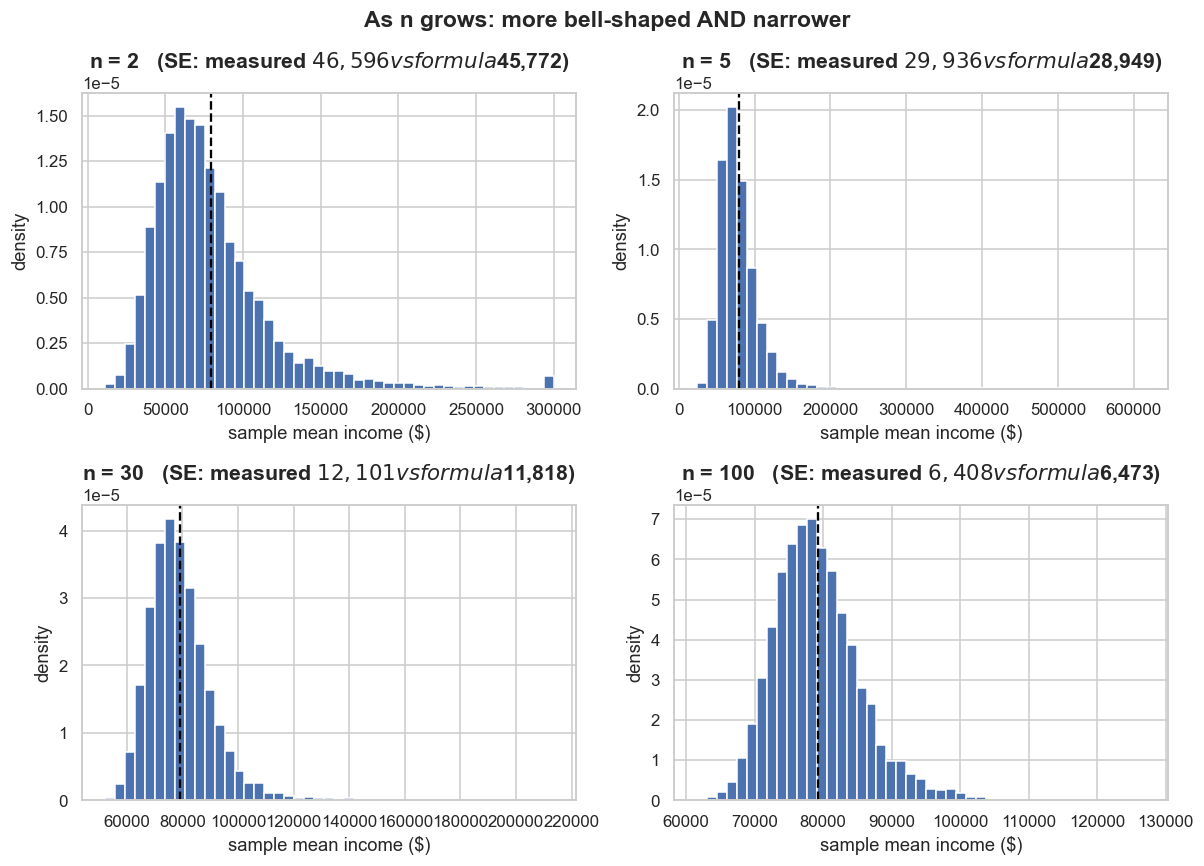

n=2 still looks lopsided (the population is extreme). By n=30 it is clearly bell-shaped,
and by n=100 it is a tight, clean bell -- exactly the Central Limit Theorem.


In [7]:
sizes = [2, 5, 30, 100]
reps = 10_000

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, n in zip(axes.ravel(), sizes):
    samples = rng.choice(pop, size=(reps, n), replace=True)   # (reps, n) array: one sample per row
    means   = samples.mean(axis=1)                            # collapse each row to its mean
    shown   = np.clip(means, None, 300_000) if n == 2 else means   # tame n=2's long tail for display
    ax.hist(shown, bins=45, density=True, color='#4c72b0', edgecolor='white')
    ax.axvline(mu, color='black', lw=1.5, ls='--')
    emp = means.std(ddof=0)
    th  = sigma / np.sqrt(n)
    ax.set_title(f'n = {n}   (SE: measured ${emp:,.0f} vs formula ${th:,.0f})')
    ax.set_xlabel('sample mean income ($)'); ax.set_ylabel('density')
fig.suptitle('As n grows: more bell-shaped AND narrower', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

print('n=2 still looks lopsided (the population is extreme). By n=30 it is clearly bell-shaped,')
print('and by n=100 it is a tight, clean bell -- exactly the Central Limit Theorem.')

### The $\sqrt{n}$ law, in one table

Let's line up the empirical SE against the formula for all four sizes at once, and add the **mean of the
means** (which should hug $\mu$ every time). This is the numeric core of the whole lesson.

In [8]:
reps = 10_000
rows = []
for n in [2, 5, 30, 100]:
    samples = rng.choice(pop, size=(reps, n), replace=True)
    means   = samples.mean(axis=1)
    rows.append({'n': n,
                 'mean_of_means': means.mean(),
                 'empirical_SE': means.std(ddof=0),
                 'formula_SE': sigma / np.sqrt(n),
                 'ratio': means.std(ddof=0) / (sigma / np.sqrt(n))})
table = pd.DataFrame(rows)
print(table.to_string(index=False, float_format=lambda v: f'{v:,.2f}'))
print()
print(f'Every mean_of_means lands near mu = ${mu:,.0f}, and every ratio is ~1.00:')
print('the empirical spread of x-bar matches sigma/sqrt(n) at each n. That is the sqrt(n) law.')
all_close = np.allclose(table['empirical_SE'], table['formula_SE'], rtol=0.05)
print('all four within 5%?', all_close)

  n  mean_of_means  empirical_SE  formula_SE  ratio
  2      78,733.61     44,925.67   45,771.77   0.98
  5      79,076.39     28,747.40   28,948.61   0.99
 30      79,450.80     12,071.00   11,818.22   1.02
100      79,273.38      6,552.35    6,473.11   1.01

Every mean_of_means lands near mu = $79,222, and every ratio is ~1.00:
the empirical spread of x-bar matches sigma/sqrt(n) at each n. That is the sqrt(n) law.
all four within 5%? True


## 4) The idiom — the loop vs. the vectorized `(reps, n)` array

In Section 3 we built the means with an explicit `for` loop. NumPy lets us do the *same thing* in one shot: ask
for a 2D array of shape **`(reps, n)`** — that's `reps` samples stacked as rows, each row a sample of `n`
incomes — then average **across each row** with `.mean(axis=1)`. Read `axis=1` as **"collapse each row to its
mean"**. Same answer, one expression, far faster on big runs.

To prove they agree, we reset the seed before each so they see the *same* random draws.

In [9]:
n, reps = 30, 10_000

# (a) the explicit loop
rng_loop = np.random.default_rng(0)
loop_means = []
for _ in range(reps):
    loop_means.append(rng_loop.choice(pop, size=n, replace=True).mean())
loop_means = np.array(loop_means)

# (b) the vectorized (reps, n) array idiom
rng_vec = np.random.default_rng(0)
samples   = rng_vec.choice(pop, size=(reps, n), replace=True)   # shape (10000, 30)
vec_means = samples.mean(axis=1)                                # one mean per row

print('samples array shape:', samples.shape, ' -> (reps, n): one sample per row')
print(f'loop       : mean of means ${loop_means.mean():,.0f}, SE ${loop_means.std(ddof=0):,.0f}')
print(f'vectorized : mean of means ${vec_means.mean():,.0f}, SE ${vec_means.std(ddof=0):,.0f}')
print('identical (same seed -> same draws)?', np.allclose(loop_means, vec_means))

samples array shape: (10000, 30)  -> (reps, n): one sample per row
loop       : mean of means $79,138, SE $11,681
vectorized : mean of means $79,138, SE $11,681
identical (same seed -> same draws)? True


In [10]:
# And the vectorized way is much faster. Time both on a big run.
import time
n, reps = 30, 50_000

t0 = time.perf_counter()
m = []
for _ in range(reps):
    m.append(rng.choice(pop, size=n, replace=True).mean())
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
_ = rng.choice(pop, size=(reps, n), replace=True).mean(axis=1)
t_vec = time.perf_counter() - t0

print(f'{reps:,} samples of n={n}:')
print(f'  Python loop          : {t_loop*1000:7.1f} ms')
print(f'  vectorized (reps, n) : {t_vec*1000:7.1f} ms')
print(f'  vectorized is roughly {t_loop/max(t_vec,1e-9):.0f}x faster -- and it is one short line.')

50,000 samples of n=30:
  Python loop          :   436.5 ms
  vectorized (reps, n) :     8.4 ms
  vectorized is roughly 52x faster -- and it is one short line.


## 5) Refactor into a reusable function

You've now written the draw-average-collect recipe a few times. The programmer's reflex is to **wrap repeated
work in a function**: name it, give it inputs, `return` the result. Then "build the sampling distribution" is
one call you can reuse for *any* `n` — or any population at all.

In [11]:
def sampling_distribution(pop, n, reps, rng):
    '''Return an array of `reps` sample means, each from a sample of size n drawn
    (with replacement) from the 1-D population array `pop`, using generator `rng`.

    This is the vectorized idiom from Section 4: one (reps, n) array, averaged per row.
    '''
    samples = rng.choice(pop, size=(reps, n), replace=True)
    return samples.mean(axis=1)

# Reuse it across the four sizes -- no copy-paste of the loop:
rng = np.random.default_rng(0)
print(f"{'n':>4} {'empirical SE':>14} {'formula SE':>14} {'match?':>8}")
for n in [2, 5, 30, 100]:
    means = sampling_distribution(pop, n, reps=10_000, rng=rng)
    emp = means.std(ddof=0)
    th  = sigma / np.sqrt(n)
    print(f'{n:>4} {emp:>14,.0f} {th:>14,.0f} {str(np.isclose(emp, th, rtol=0.05)):>8}')

   n   empirical SE     formula SE   match?
   2         43,919         45,772     True
   5         28,097         28,949     True
  30         11,879         11,818     True
 100          6,513          6,473     True


A function is a contract: *give me a population, an `n`, a number of reps and a generator, I'll give you the
sampling distribution.* Once it's correct, you stop thinking about loops and start thinking in **populations,
sample sizes and standard errors** — exactly the leap from "watching the CLT" to "simulating it in code."

## 6) Now you code

Write the code yourself. Add a new cell (the **+** button in the toolbar) and try each — predict the answer
before you run it.

1. **Quadruple $n$, halve the SE.** Use `sampling_distribution(pop, n, 10_000, rng)` to get the empirical SE
   at `n = 25` and at `n = 100` (a 4× jump). Predict the *ratio* of the two SEs before you run — the $\sqrt{n}$
   law says it should be near **2.00**.

2. **Center on $\mu$.** For `n = 50`, build the means and print `means.mean()` next to `mu`. They should be
   very close. Why is the mean of the sample means an (almost) unbiased estimate of $\mu$?

3. **A different column.** The CLT works on *any* population. Set `pop2 = loans['loan_amount'].dropna().to_numpy()`
   and its `sigma2 = pop2.std(ddof=0)`, then call `sampling_distribution(pop2, 30, 10_000, rng)`. Does the
   empirical SE still match `sigma2 / np.sqrt(30)`? (It should.)

4. **Loop vs. vectorized, your turn.** Re-create the `n = 30` means with an explicit `for` loop *and* with the
   `(reps, n)` array idiom, each seeded with `np.random.default_rng(1)`. Confirm they're identical with
   `np.allclose(...)`, then time both — by how much does vectorizing win?

## What you learned

**Coding**
- NumPy's **random generator** `rng = np.random.default_rng(0)` gives reproducible randomness; `rng.choice(pop,
  size=..., replace=True)` draws samples, and `replace=True` means "with replacement."
- The **sampling-distribution recipe** is draw → average → repeat. The literal `for`-loop and the **vectorized
  `(reps, n)` array** (then `.mean(axis=1)`, "collapse each row to its mean") give the *same* answer — but the
  array is one line and far faster.
- Use `np.isclose` / `np.allclose` to **check two numbers agree** to a tolerance — the programmer's way to
  confirm a formula against a simulation.
- **Refactor repeated work into a function** with clear inputs, a docstring and a `return`, then reuse it for
  any `n` or any population.

**Statistics (now demystified)**
- The **sampling distribution of the mean** is just the pile of sample means you get by repeating "draw $n$,
  average." You built it from scratch.
- The **Central Limit Theorem**: from a population with mean $\mu \approx \$79{,}000$ and SD
  $\sigma \approx \$65{,}000$ that is *wildly* right-skewed, the sample means still form a **bell curve
  centered on $\mu$** — sharper and more bell-like as $n$ grows.
- The **standard error** $\text{SE} = \sigma/\sqrt{n}$ is the spread of that bell. Your simulation matched it
  at every $n$ (ratios ≈ 1.00), and the **mean of the means** landed on $\mu$ every time. The $\sqrt{n}$ law
  means **quadrupling $n$ only halves the error**.
- Use **`ddof=0`** for $\sigma$ when the dataset *is* the whole population, so $\sigma/\sqrt{n}$ matches the
  measured spread honestly.

**Back to the core lesson** ([Lesson 10: Sampling distributions & the Central Limit Theorem](10-sampling-distributions-clt.ipynb))
for the *meaning* of these numbers, or read on through the course.

---

**↩ Back to the lesson:** [Lesson 10: Sampling distributions & the Central Limit Theorem](10-sampling-distributions-clt.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset](10-sampling-distributions-clt~another-dataset.ipynb)